In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from numpy.linalg import LinAlgError


from sklearn.metrics import mean_squared_error as mse

from statsmodels.tsa.seasonal import seasonal_decompose as sd
from statsmodels.tsa.stattools import adfuller as adf
from statsmodels.tsa.arima.model import ARIMA

import warnings
warnings.filterwarnings('ignore')

from datetime import datetime

from prophet import Prophet
from math import sqrt

import plotly.graph_objs as go
import plotly.offline as py

In [2]:
# Data
data = pd.read_csv(r"E:\DATA FOR TEST\AirPassengers.csv")
df = data.copy()
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

# Log Conversion
log_df = np.log(df)
# log_df = log_df.values

# Train Test Split
size = int(len(log_df) * 0.8)
train, test = log_df[: size], log_df[size : ]

In [3]:
# Parameter Grid Search by Arima
p_values=[0, 1, 2, 3, 4, 5]
d_values=[0, 1, 2, 3, 4, 5]
q_values=[0, 1, 2, 3, 4, 5]

best_rmse, best_order = np.inf, None
count = 1

for p in p_values:
    for d in d_values:
        for q in q_values:
            
            order = (p, d, q)
            
            try:
                model = ARIMA(train, order=order)
                model_fit = model.fit()
                model_predict = model_fit.forecast(steps=len(test))

                rmse = np.sqrt(mse(test, model_predict))

                if best_rmse > rmse:
                    best_rmse = rmse
                    best_order = order
                
                # print(f'{count}. RMSE : {rmse} by Order of {order}')
                # count += 1
                
            except:
                continue
print(f'\nBest RMSE : {best_rmse} by Order : {best_order}')


Best RMSE : 0.15316090355897993 by Order : (1, 1, 5)


In [4]:
# Better Approach
best_rmse, best_p, best_d, best_q = np.inf, None, None, None
p_values = [0, 1, 2]
d_values = [0, 1, 2]
q_values = [0, 1, 2]

for p in p_values:
    for d in d_values:
        for q in q_values:
            
            order = (p, d, q)
            
            try:
                history = list(train.values)
                predictions = []
                    
                for t in range(len(test)):
                    model = ARIMA(history, order=order)
                    model_fit = model.fit()
                    prediction = model_fit.forecast()[0]
                    
                    predictions.append(prediction)
                    history.append(test.values[t])

                rmse = np.sqrt(mse(test, predictions))
                if rmse < best_rmse:
                    best_rmse, best_p, best_d, best_q = rmse, p, d, q
            except:   #or (ValueError, LinAlgError)
                continue # or Pass

print('best_rmse :', best_rmse)
print('best P :', best_p)
print('best D :', best_d)
print('best Q :', best_q)

best_rmse : 0.09998221906665214
best P : 2
best D : 1
best Q : 1


In [6]:
# ARIMA Model

history = list(train.values)
predictions = []
        
for t in range(len(test)):
    model = ARIMA(history, order=(2, 1, 1))
    model_fit = model.fit()
    prediction = model_fit.forecast()[0]
    
    predictions.append(prediction)
    history.append(test.values[t])
rmse = np.sqrt(mse(test.values, predictions))

print('RMSE :', rmse)

RMSE : 0.09998221906665214


In [25]:
actual = np.exp(test.values)
predicted = np.exp(predictions)

rmse = np.sqrt(mse(actual, predicted))

print('RMSE :', rmse)

RMSE : 44.68206614418277


In [26]:
# Actual Predicted
for actual, predicted in zip(np.exp(test.values), np.exp(predictions)):
    print(f"{actual[0]:.4f}    {predicted:.4f}")

505.0000    474.6563
404.0000    474.1809
359.0000    367.4340
310.0000    353.8264
337.0000    312.6080
360.0000    362.5022
342.0000    374.0932
406.0000    342.3674
396.0000    422.5841
420.0000    384.3647
472.0000    416.1525
548.0000    465.7731
559.0000    532.4843
463.0000    520.7805
407.0000    421.0075
362.0000    394.9731
405.0000    363.4184
417.0000    431.4373
391.0000    423.3620
419.0000    388.4226
461.0000    430.2925
472.0000    465.7003
535.0000    461.3687
622.0000    529.9373
606.0000    604.8798
508.0000    558.5180
461.0000    465.4310
390.0000    451.0615
432.0000    386.2075


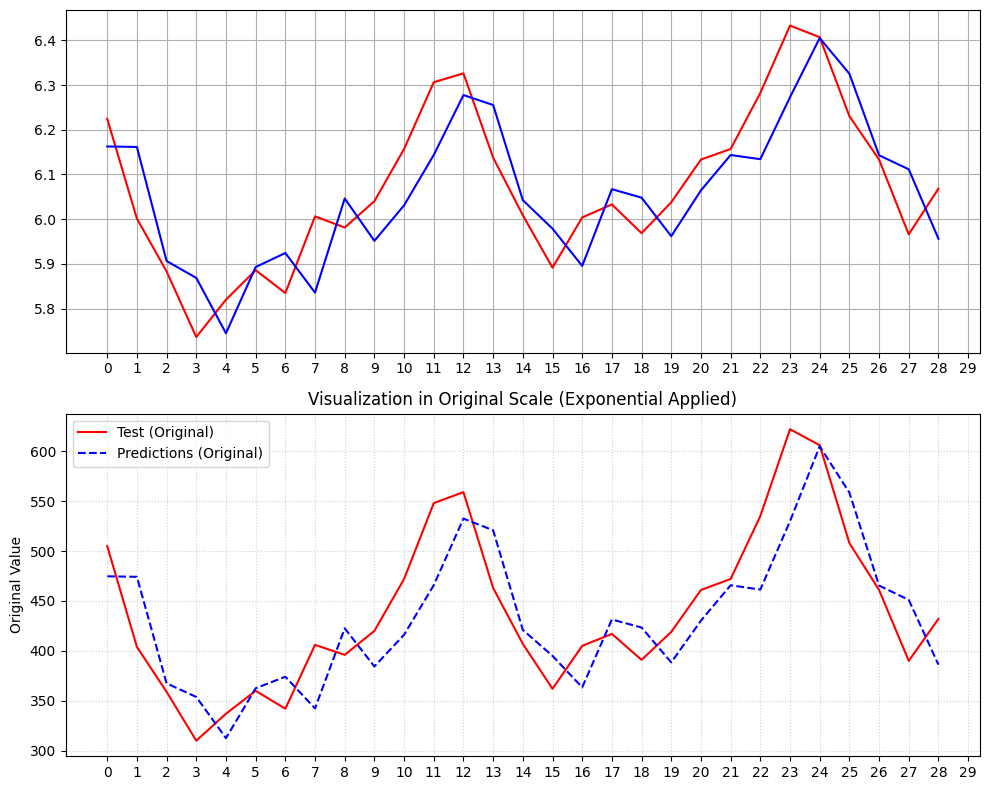

In [27]:
# Plot Visulization
fig, axes = plt.subplots(2, figsize=(10, 8))

# --- Upper PLOT (Log Scale) ---
axes[0].plot(test.values, color='red', label='Test')
axes[0].plot(predictions, color='blue', label='Predictions')
axes[0].set_xticks(range(0, 30))
axes[0].grid()

# --- Lower PLOT (Original Scale) ---
axes[1].plot(np.exp(test.values), color='red', label='Test (Original)', linewidth=1.5)
axes[1].plot(np.exp(predictions), color='blue', label='Predictions (Original)', linestyle='--', linewidth=1.5)
axes[1].set_title('Visualization in Original Scale (Exponential Applied)')
axes[1].set_ylabel('Original Value')
axes[1].set_xticks(range(0, 30))
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend()


# 2. Layout ko clean karna
plt.tight_layout()
plt.show()